### Importacion de librerias

In [7]:
!pip install openpyxl
!pip install -U scikit-learn
!pip install -U imbalanced-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
# Modelos y herramientas de Scikit-learn
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Importaciones para Imbalanced-learn
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE 

# Importación para el clasificador de Boosting
from xgboost import XGBClassifier


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

  Using cached scikit_learn-1.7.0-cp312-cp312-win_amd64.whl.metadata (14 kB)
Using cached scikit_learn-1.7.0-cp312-cp312-win_amd64.whl (10.7 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.0 which is incompatible.


  Using cached scikit_learn-1.6.1-cp312-cp312-win_amd64.whl.metadata (15 kB)
Using cached scikit_learn-1.6.1-cp312-cp312-win_amd64.whl (11.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.0
    Uninstalling scikit-learn-1.7.0:
      Successfully uninstalled scikit-learn-1.7.0


In [11]:
import warnings
# Ignoramos algunos warnings que se producen por invocar el modelo sin el nombre de las características
warnings.filterwarnings('ignore', category=UserWarning, message='.*X does not have valid feature names.*')

### Funciones Auxiliares

In [12]:
# Construcción de una función que realice el particionado completo
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

In [13]:
def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [14]:
def evaluate_result(y_pred, y, y_prep_pred, y_prep, metric):
    print(metric.__name__, "Sin preparación:", metric(y_pred, y, average='weighted'))
    print(metric.__name__, "Con preparación:", metric(y_prep_pred, y_prep, average='weighted'))

### Cargar datos formato excel

In [15]:
# Cargando archivos Xlsx
ruta_archivo = 'datasets.xlsx'
df = pd.read_excel(ruta_archivo)

In [16]:
# Configuramos opciones de visualización para ver todas las columnas del DataFrame.
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 10)

### Visualización de los datos

In [17]:
df.head(10)

,ENTREVISTADOR,REGISTRO,DC5_DC,DC7_DC_1_1,DC7_DC_1_2,...,URBANIZACION_RESIDEN,REGION,MUNICIPIO,NOMBRE,CIUDAD_RESIDENCIA
0,Autoadministrado sin contacto,1216,2,Otras ocupaciones,NaN,...,NaN,Capital,Sucre (Petare),NaN,NaN
1,Autoadministrado sin contacto,2685,2,NaN,NaN,...,27 DE FEBRERO,Capital,Plaza (Guarenas),JAIRO CABRERA,GUARENAS
2,Autoadministrado sin contacto,5167,2,Trabajadores por cuenta propia / Libre ejercic...,Trabajadores en el comercio informal,...,AVENIDA JUAN DE CASTELLANO. URBANIZACIÓN TARI...,Oriental,Marcano (Juan Griego),JUAN JOSE ADRIAN,JUANGRIEGO. NVA ESPARTA. ISLA DE MARGARITA
3,Autoadministrado sin contacto,5003,3,Patronos o empleadores (empresarios/ comercian...,Jubilados o con pensión venezolana,...,LOS ROBLES,Oriental,Maneiro (Pampatar),REYNALDO JAIME,MARGARITA
4,Autoadministrado sin contacto,5179,2,NaN,NaN,...,PUEBLO NUEVO,Centro Occidental,No sabe,EVA PERDOMO,ARAURE
5,Autoadministrado sin contacto,22,1,Patronos o empleadores (empresarios/ comercian...,NaN,...,NaN,Capital,Baruta (Baruta),NaN,NaN
6,Autoadministrado sin contacto,5259,2,Empleados de la empresa privada,NaN,...,LA LAGO,Zuliana,Maracaibo (Maracaibo),LILIBETH ROSALES,MARACAIBO
7,Autoadministrado sin contacto,4391,1,NaN,NaN,...,PARROQUIA UNARE,Guayana,Caroní (Ciudad Guayana),AIXA COROMOTO GÓMEZ AGUILERA,PUERTO ORDAZ
8,Autoadministrado sin contacto,5125,5,Trabajadores independientes en oficios calific...,NaN,...,NaN,Zuliana,Lagunillas (Ciudad Ojeda),CAROLINA MACHADO,NaN
9,Autoadministrado sin contacto,5126,3,Patronos o empleadores (empresarios/ comercian...,NaN,...,1 MAYO,Zuliana,Colón (San Carlos del Zulia),MARIA URDANETA,"SAN CARLOS, ZULIA/EL VIGÍA, MERIDA"


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ENTREVISTADOR         800 non-null    object 
 1   REGISTRO              800 non-null    int64  
 2   DC5_DC                800 non-null    int64  
 3   DC7_DC_1_1            661 non-null    object 
 4   DC7_DC_1_2            227 non-null    object 
 5   DC7_DC_1_3            58 non-null     object 
 6   DC7_DC_1_4            15 non-null     object 
 7   DC7_DC_1_5            5 non-null      object 
 8   DC7_DC_1_6            2 non-null      object 
 9   DC7_DC_1_7            1 non-null      object 
 10  DC7_DC_1_8            1 non-null      object 
 11  DC8_DC                800 non-null    int64  
 12  DC8_DC_18             800 non-null    int64  
 13  DC8_DC_M18            412 non-null    float64
 14  DC8_DC_T              800 non-null    int64  
 15  DC3_DC_1              8

In [19]:
df.describe()

,REGISTRO,DC5_DC,DC8_DC,DC8_DC_18,DC8_DC_M18,DC8_DC_T,SUMA
count,800.000000,800.000000,800.00000,800.000000,412.000000,800.00000,800.000000
mean,3196.750000,2.142500,3.84375,2.802500,2.021845,3.84375,3.501250
std,1956.909325,1.797563,1.90496,1.371439,1.230990,1.90496,2.158894
min,22.000000,1.000000,1.00000,1.000000,1.000000,1.00000,0.000000
25%,1084.250000,1.000000,3.00000,2.000000,1.000000,3.00000,2.000000
50%,3333.500000,2.000000,4.00000,3.000000,2.000000,4.00000,3.000000
75%,5149.250000,2.000000,5.00000,4.000000,3.000000,5.00000,5.000000
max,5342.000000,20.000000,16.00000,12.000000,15.000000,16.00000,11.000000


En esta sección visualizamos el numero de clases que hay en la variable objetiva

In [20]:
df['NSE'].value_counts()

NSE
E    371
D    323
C    106
Name: count, dtype: int64

La distribución que muestras (E: 371, D: 323, C: 106) no parece extremadamente desproporcionada en el sentido de que una clase sea minúscula y las otras gigantes. Sí hay un desequilibrio (C es significativamente más pequeña que E o D), pero no es de 1000 a 10.

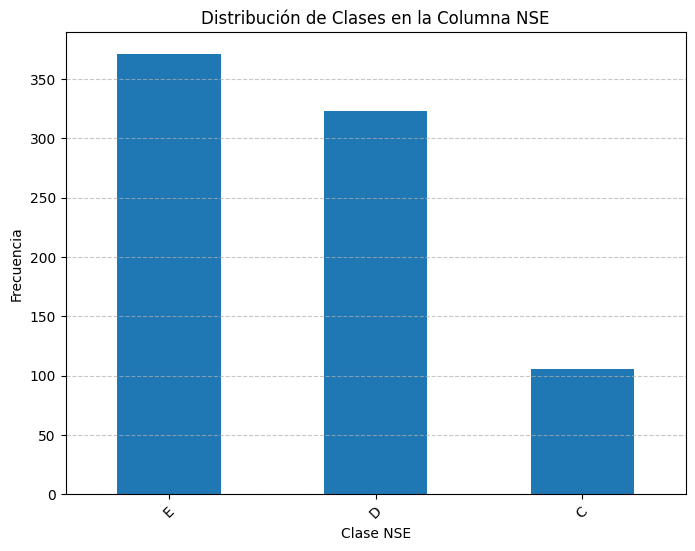

In [21]:
# Después de df['NSE'].value_counts()
plt.figure(figsize=(8, 6))
df['NSE'].value_counts().plot(kind='bar')
plt.title('Distribución de Clases en la Columna NSE')
plt.xlabel('Clase NSE')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [22]:
# Comprobación de si existen valores nulos
is_null = df.isna().any()
is_null[is_null]

DC7_DC_1_1              True
DC7_DC_1_2              True
DC7_DC_1_3              True
DC7_DC_1_4              True
DC7_DC_1_5              True
                        ... 
DC7_DC_1_8              True
DC8_DC_M18              True
URBANIZACION_RESIDEN    True
NOMBRE                  True
CIUDAD_RESIDENCIA       True
Length: 12, dtype: bool

In [23]:
# Comprobación de la existencia de valores infinitos
is_inf = df.isin([np.inf, -np.inf]).any()
is_inf[is_inf]

Series([], dtype: bool)

Confirmación de Valores Nulos: La fila count muestra un número de registros diferente para cada variable. Esto confirma lo que ya sabíamos: hay una cantidad variable de datos nulos en cada columna.

### Intuiciones
 <span style="color:green">¿Los valores se encuentran muy dispares?</span> Sí. Al comparar la media (mean) con la mediana (50%), se observa que en muchas columnas estos dos valores son diferentes. Por ejemplo, en la variable DC8_DC_T (total de personas en el hogar), la media es 4.4 y la mediana es 4.0. Aunque no es una diferencia abismal, indica un ligero sesgo.

<span style="color:green">En otras variables, esta diferencia puede ser mayor</span>. Cuando la media y la mediana difieren significativamente, es una señal clara de que la distribución de los datos está sesgada (asimétrica) y/o existen valores atípicos (outliers).

<span style="color:red">Eliminar Filas:</span> Si eliminas cada fila que tenga al menos un valor nulo, podrías terminar con una fracción muy pequeña de tu conjunto de datos original. Perderías muchísima información valiosa y el modelo resultante sería pobre.

<span style="color:green">¿Es la Mediana una Buena Estrategia de Imputación?</span>
mi hipotesis es preparar los datos cambiando los valores nulos por la mediana

Tu hipótesis es excelente y la más recomendada para tus datos numéricos.

### Imputación 

Dado que hemos visto que tus datos numéricos tienen sesgo y posibles valores atípicos (son "dispares"), la mediana es la mejor opción para la imputación por las siguientes razones:

Robustez ante Outliers: La mediana no se ve afectada por valores extremos, a diferencia de la media. Si en la variable "ingresos" tienes a una persona que gana 100 veces más que el resto, la media se disparará, pero la mediana seguirá representando el valor central de la población.
Mejor Representación del Centro: En una distribución asimétrica, la mediana es un mejor indicador del "valor típico" que la media.

Mejor Representación del Centro: En una distribución asimétrica, la mediana es un mejor indicador del "valor típico" que la media.
¿Qué pasa con las variables categóricas?
No puedes calcular la mediana de variables como DC7_DC_1_1 ("Ocupación"). Para estas, la estrategia estándar es imputar con la moda (el valor más frecuente).

Estrategia de Imputación Recomendada:

Para tus variables numéricas: Usa la mediana.
Para tus variables categóricas (de texto): Usa la moda (el valor más común).

### División del Conjunto de datos 60% 20% 20%
Vamos a usar Estratificación de los datos para mantener las proporciones homogeneas de la variable objetiva en cada conjunto de datos

In [24]:
# División del conjunto de datos
train_set, val_set, test_set = train_val_test_split(df)

In [25]:
X_train, y_train = remove_labels(train_set, 'NSE')
X_val, y_val = remove_labels(val_set, 'NSE')
X_test, y_test = remove_labels(test_set, 'NSE')

In [26]:
# Inicializamos el transformador para la imputación
imputer = SimpleImputer(strategy="median")

In [27]:
# Separamos las columnas númericas 
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Columnas Numéricas Identificadas:")
print(numeric_cols)
print("\nColumnas Categóricas Identificadas:")
print(categorical_cols)


Columnas Numéricas Identificadas:
['REGISTRO', 'DC5_DC', 'DC8_DC', 'DC8_DC_18', 'DC8_DC_M18', 'DC8_DC_T', 'SUMA']

Columnas Categóricas Identificadas:
['ENTREVISTADOR', 'DC7_DC_1_1', 'DC7_DC_1_2', 'DC7_DC_1_3', 'DC7_DC_1_4', 'DC7_DC_1_5', 'DC7_DC_1_6', 'DC7_DC_1_7', 'DC7_DC_1_8', 'DC3_DC_1', 'DC3_DC_2', 'DC3_DC_3', 'DC3_DC_4', 'DC3_DC_5', 'DC3_DC_6', 'DC3_DC_7', 'DC3_DC_8', 'DC3_DC_9', 'DC3_DC_10', 'DC3_DC_11', 'DC6_DC_P', 'DC4_DC', 'DC9_DC', 'DC10_DC', 'URBANIZACION_RESIDEN', 'REGION', 'MUNICIPIO', 'NOMBRE', 'CIUDAD_RESIDENCIA']


In [28]:
# ==============================================================================
# INICIO DEL PLAN DE ACCIÓN: PREPROCESAMIENTO DE DATOS (Versión Corregida)
# ==============================================================================

# --- PASO 1: SEPARAR COLUMNAS NUMÉRICAS Y CATEGÓRICAS ---
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Columnas Numéricas Identificadas:")
print(numeric_cols)
print("\nColumnas Categóricas Identificadas:")
print(categorical_cols)


# --- PASO 2: IMPUTAR VALORES NULOS (Estrategia Separada y Robusta) ---
X_train_prep = X_train.copy()
X_val_prep = X_val.copy()
X_test_prep = X_test.copy()

# 2.1) Imputación para variables NUMÉRICAS con la MEDIANA (sin cambios)
imputer_numeric = SimpleImputer(strategy='median')
X_train_prep[numeric_cols] = imputer_numeric.fit_transform(X_train_prep[numeric_cols])
X_val_prep[numeric_cols] = imputer_numeric.transform(X_val_prep[numeric_cols])
X_test_prep[numeric_cols] = imputer_numeric.transform(X_test_prep[numeric_cols])

# 2.2) Imputación para variables CATEGÓRICAS con la MODA
# --- INICIO DE LA CORRECCIÓN ---
# ANTES de imputar, convertimos todas las columnas categóricas a tipo 'string'.
# Esto previene el error 'NoneType' al estandarizar los datos.
for col in categorical_cols:
    X_train_prep[col] = X_train_prep[col].astype(str)
    X_val_prep[col] = X_val_prep[col].astype(str)
    X_test_prep[col] = X_test_prep[col].astype(str)
# --- FIN DE LA CORRECCIÓN ---

imputer_categorical = SimpleImputer(strategy='most_frequent')
X_train_prep[categorical_cols] = imputer_categorical.fit_transform(X_train_prep[categorical_cols])
X_val_prep[categorical_cols] = imputer_categorical.transform(X_val_prep[categorical_cols])
X_test_prep[categorical_cols] = imputer_categorical.transform(X_test_prep[categorical_cols])

print("\n¡Imputación de valores nulos completada!")


# --- PASO 3: CODIFICAR VARIABLES CATEGÓRICAS (One-Hot Encoding) ---
# Ahora el valor que antes era nulo (ej: 'nan' o 'None') será tratado como una categoría más.
X_train_encoded = pd.get_dummies(X_train_prep, columns=categorical_cols, drop_first=True)
X_val_encoded = pd.get_dummies(X_val_prep, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_prep, columns=categorical_cols, drop_first=True)

# Alinear columnas para asegurar que todos los dataframes tengan las mismas dimensiones
X_train_final, X_val_final = X_train_encoded.align(X_val_encoded, join='left', axis=1, fill_value=0)
X_train_final, X_test_final = X_train_final.align(X_test_encoded, join='left', axis=1, fill_value=0)

X_val_final = X_val_final.fillna(0)
X_test_final = X_test_final.fillna(0)


print("\n¡Codificación One-Hot completada y columnas alineadas!")
print("Dimensiones de los datos finales:")
print("X_train_final:", X_train_final.shape)
print("X_val_final:", X_val_final.shape)
print("X_test_final:", X_test_final.shape)

# ==============================================================================
# FIN DEL PLAN DE ACCIÓN
# ==============================================================================

Columnas Numéricas Identificadas:
['REGISTRO', 'DC5_DC', 'DC8_DC', 'DC8_DC_18', 'DC8_DC_M18', 'DC8_DC_T', 'SUMA']

Columnas Categóricas Identificadas:
['ENTREVISTADOR', 'DC7_DC_1_1', 'DC7_DC_1_2', 'DC7_DC_1_3', 'DC7_DC_1_4', 'DC7_DC_1_5', 'DC7_DC_1_6', 'DC7_DC_1_7', 'DC7_DC_1_8', 'DC3_DC_1', 'DC3_DC_2', 'DC3_DC_3', 'DC3_DC_4', 'DC3_DC_5', 'DC3_DC_6', 'DC3_DC_7', 'DC3_DC_8', 'DC3_DC_9', 'DC3_DC_10', 'DC3_DC_11', 'DC6_DC_P', 'DC4_DC', 'DC9_DC', 'DC10_DC', 'URBANIZACION_RESIDEN', 'REGION', 'MUNICIPIO', 'NOMBRE', 'CIUDAD_RESIDENCIA']

¡Imputación de valores nulos completada!

¡Codificación One-Hot completada y columnas alineadas!
Dimensiones de los datos finales:
X_train_final: (480, 1297)
X_val_final: (160, 1297)
X_test_final: (160, 1297)


In [29]:
#Visualizamos el conjunto final
X_train_final

,REGISTRO,DC5_DC,DC8_DC,DC8_DC_18,DC8_DC_M18,...,CIUDAD_RESIDENCIA_YARITAGUA,CIUDAD_RESIDENCIA_ZARAZA,CIUDAD_RESIDENCIA_ZULIA,CIUDAD_RESIDENCIA_ZULIA JESÚS MARÍA SEMPRÚN. CASIGUA EL CUBO,CIUDAD_RESIDENCIA_nan
766,873.0,2.0,6.0,2.0,4.0,...,False,False,False,False,False
257,3434.0,1.0,1.0,1.0,2.0,...,False,False,False,False,False
765,5143.0,1.0,7.0,7.0,2.0,...,False,False,False,False,False
543,1747.0,2.0,3.0,3.0,2.0,...,False,False,False,False,False
15,5165.0,2.0,5.0,3.0,2.0,...,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
71,5042.0,2.0,3.0,3.0,2.0,...,False,False,False,False,False
106,1264.0,2.0,2.0,2.0,2.0,...,False,False,False,False,True
270,5282.0,1.0,3.0,2.0,1.0,...,False,False,False,False,False
435,2558.0,2.0,3.0,3.0,2.0,...,False,False,False,False,False


## Intuiciones

¿Por qué aumentó tanto el número de columnas (de ~30 a 203)?
Esto se debe al One-Hot Encoding (pd.get_dummies). Recuerda que los algoritmos como Random Forest no entienden texto ("Casado", "Apartamento", etc.), solo entienden números.

Lo que hace One-Hot Encoding es tomar una columna categórica y crear nuevas columnas numéricas para cada una de sus categorías.

Imagina que tu columna DC10_DC (Tipo de vivienda) tiene 3 categorías: "Casa", "Apartamento" y "Rancho".

Antes de la codificación: Tenías 1 columna (DC10_DC).
Después de get_dummies: El código transforma esa columna en 2 nuevas columnas (usamos drop_first=True para eliminar una y evitar redundancia):
| DC10_DC (Original) | → | DC10_DC_Apartamento | DC10_DC_Rancho |
| :--- | :-: | :---: | :---: |
| "Casa" | → | 0 | 0 |
| "Apartamento" | → | 1 | 0 |
| "Rancho" | → | 0 | 1 |

El código hizo este proceso para todas tus columnas categóricas (DC7_DC_1_1, DC9_DC, etc.). La suma de tus columnas numéricas originales más todas estas nuevas columnas creadas da como resultado las 203 columnas finales.

¿Qué significa (480, 203)?
Esto representa la dimensión (shape) de tu conjunto de datos de entrenamiento final:

480 filas: El 60% de tus datos originales, que se usarán para que el modelo aprenda.
203 columnas: Las características (features) que el modelo usará para aprender a predecir el NSE. Todas son 100% numéricas.
¿Y qué es eso de "Columnas Alineadas"?
Es un paso de seguridad crucial. A veces, el conjunto de validación (X_val) puede no tener una categoría que sí está en el de entrenamiento (X_train). Si no las alineamos, X_train podría tener 203 columnas y X_val 201, lo que daría un error. El comando .align() asegura que los tres conjuntos de datos (train, val y test) tengan exactamente las mismas 203 columnas en el mismo orden, rellenando con 0 si alguna falta.

### Valores Booleanos?

<span style="color:green">¿El Modelo Entiende los Valores Booleanos</span> (True/False)?
y una pregunta el modelo entinede esos valores booleanos que dicen false?

La respuesta es: Sí, perfectamente.

Esta es una excelente observación. Al ver dtype: bool en la imagen, es normal preguntarse si el modelo puede manejarlo.

En el mundo de la computación y de librerías como pandas y scikit-learn, los valores booleanos son tratados matemáticamente como números enteros:

True se interpreta como 1.
False se interpreta como 0.

### Convertir nuestra variable objetiva a númerica con la tecnica de Encoding

<span style="color:blue">Cómo Funciona LabelEncoder?</span>
Es muy sencillo. LabelEncoder toma una columna con etiquetas de texto y hace dos cosas:

Encuentra todas las categorías únicas (en tu caso, 'C', 'D', 'E').
Asigna un número entero a cada una (por ejemplo: 'C' → 0, 'D' → 1, 'E' → 2).
Una gran ventaja es que el LabelEncoder "recuerda" este mapeo, por lo que más tarde, cuando tu modelo prediga un 1, puedes usar el mismo codificador para que te diga que la predicción real es 'D'.

In [30]:
# Creamos una instancia del LabelEncoder
label_encoder = LabelEncoder()

In [31]:
# Ajustamos el codificador y transformamos y_train. 
# El .fit() aprende la relación ('C'->0, 'D'->1, etc.) y .transform() la aplica.
y_train_encoded = label_encoder.fit_transform(y_train)

In [32]:
# Para los conjuntos de validación y prueba, SÓLO transformamos,
# ya que deben usar el mismo mapeo aprendido de y_train.
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

In [33]:
# (Opcional pero muy recomendado) Verifiquemos el mapeo que ha creado
print("Mapeo de la variable objetivo 'NSE':")
mapeo_clases = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(mapeo_clases)

# Por ejemplo, la salida podría ser: {'C': 0, 'D': 1, 'E': 2}

Mapeo de la variable objetivo 'NSE':
{'C': np.int64(0), 'D': np.int64(1), 'E': np.int64(2)}


### --- FIN DEL PREPROCESAMIENTO --- 

Considerar class_weight='balanced' en tu RandomForestClassifier para que el algoritmo dé más peso a las clases minoritarias. ya que las clases se encuentran ligeramente en desbalance Técnicas de oversampling (ej. SMOTE) o undersampling (ej. NearMiss) para balancear el dataset antes del entrenamiento.
Usar métricas de evaluación adecuadas para clases desbalanceadas (F1-score, Recall, Precision por clase, Matriz de Confusión)


## Algoritmo Random Forests¶

Al estar dispuesto a invertir tiempo computacional, podemos usar las técnicas más exhaustivas para encontrar la mejor configuración posible.

Basado en tus requerimientos (manejar desbalanceo y encontrar los mejores hiperparámetros sin importar el tiempo), la estrategia definitiva es usar GridSearchCV junto con Cross-Validation.

### Aplicación

Probará Exhaustivamente: Le daremos una "rejilla" (un diccionario) con todos los hiperparámetros que quieres probar para RandomForestClassifier. GridSearchCV entrenará un modelo para cada combinación posible de estos parámetros.

Manejará el Desbalanceo: Incluiremos el parámetro class_weight dentro de la rejilla. De esta forma, la búsqueda no solo encontrará la mejor combinación de número de árboles o profundidad, sino que también determinará si el modelo funciona mejor con el peso de clases balanceado, o sin él.

Usará Validación Cruzada (CV): Para evitar el azar y asegurar que los resultados sean robustos, GridSearchCV divide los datos de entrenamiento en varias partes (por ejemplo, 5 "folds"). Entrena el modelo en 4 partes y lo valida en la 5ta, repitiendo el proceso 5 veces. La puntuación final de cada combinación de hiperparámetros es el promedio de estas 5 validaciones.

Optimizará para la Métrica Correcta: Lo configuraremos para que su único objetivo sea maximizar el F1-Score ponderado, que es la métrica ideal para tu problema de clases desbalanceadas.

Al final, te entregará la combinación de hiperparámetros que obtuvo el mejor F1-Score promedio.

In [35]:
# ===================================================================================
# CÓDIGO FINAL: BÚSQUEDA EFICIENTE CON RandomizedSearchCV
# ===================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- INICIO DE LA CORRECCIÓN: Se importa RandomizedSearchCV ---
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
# --- FIN DE LA CORRECCIÓN ---

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# --- PASO 0: VERIFICACIONES Y CONFIGURACIÓN (Sin cambios) ---
print("--- Verificaciones de Datos de Entrenamiento ---")
class_counts = pd.Series(y_train_encoded).value_counts()
min_samples_in_minority_class = class_counts.min()
smote_k_neighbors_base = min(min_samples_in_minority_class - 1, 5)
if smote_k_neighbors_base < 1: smote_k_neighbors_base = 1
print(f"Número mínimo de muestras: {min_samples_in_minority_class}")
print(f"Valor seguro de k_neighbors para SMOTE: {smote_k_neighbors_base}")
print("--------------------------------------------------\n")

# --- PASO 1: Definir el Pipeline (Sin cambios) ---
pipeline = Pipeline([
    ('sampling', SMOTETomek(random_state=42, smote=SMOTE(k_neighbors=smote_k_neighbors_base, random_state=42))),
    ('classifier', XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False, n_jobs=1)) # n_jobs=1 en el modelo
])

# --- PASO 2: Definir la Rejilla de Hiperparámetros (Ahora se llama 'param_dist' por convención) ---
param_dist = {
    'classifier__n_estimators': [200, 400, 600, 800, 1000],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'classifier__max_depth': [3, 5, 7, 9, 11],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'classifier__reg_alpha': [0, 0.001, 0.01, 0.1, 1],
    'classifier__reg_lambda': [1, 0.1, 0.01, 0.001]
}

# --- PASO 3: Configurar y Ejecutar RandomizedSearchCV ---
n_splits_safe = min(min_samples_in_minority_class, 5)
cv_strategy = StratifiedKFold(n_splits=n_splits_safe, shuffle=True, random_state=42)

# --- INICIO DE LA CORRECCIÓN: Usamos RandomizedSearchCV ---
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist, # Nota el cambio de nombre del parámetro
    n_iter=100, # ¡LA CLAVE! Solo probará 100 combinaciones aleatorias. Ajusta este número según el tiempo que tengas.
    cv=cv_strategy,
    n_jobs=-1, # -1 para usar todos los núcleos en la búsqueda
    verbose=2, # verbose=2 para ver el progreso
    scoring='f1_weighted',
    random_state=42, # Para que la búsqueda aleatoria sea reproducible
    error_score='raise'
)
# --- FIN DE LA CORRECCIÓN ---

print(f"\n¡ATENCIÓN! Iniciando búsqueda ALEATORIA de {random_search.n_iter} combinaciones.")
random_search.fit(X_train_final, y_train_encoded)


# --- PASO 4: Analizar Resultados ---
print("\n¡Búsqueda aleatoria completada!")
print("\nLos mejores hiperparámetros encontrados son:")
print(random_search.best_params_)

print("\nMejor F1-Score (ponderado) en validación cruzada:")
print(random_search.best_score_)

best_pipeline = random_search.best_estimator_

print("\n--- Evaluación del Mejor Modelo en el Conjunto de Prueba ---")
y_pred_test = best_pipeline.predict(X_test_final)
print(classification_report(y_test_encoded, y_pred_test, target_names=label_encoder.classes_))

# (El código para la matriz de confusión no cambia)

--- Verificaciones de Datos de Entrenamiento ---
Número mínimo de muestras: 56
Valor seguro de k_neighbors para SMOTE: 5
--------------------------------------------------


¡ATENCIÓN! Iniciando búsqueda ALEATORIA de 100 combinaciones.
Fitting 5 folds for each of 100 candidates, totalling 500 fits


C:\Users\roome\anaconda3\envs\MachineLearning_entorno_fran\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:54:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



¡Búsqueda aleatoria completada!

Los mejores hiperparámetros encontrados son:
{'classifier__subsample': 0.9, 'classifier__reg_lambda': 0.01, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 1000, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0.1, 'classifier__colsample_bytree': 1.0}

Mejor F1-Score (ponderado) en validación cruzada:
0.8628095278419838

--- Evaluación del Mejor Modelo en el Conjunto de Prueba ---
              precision    recall  f1-score   support

           C       0.92      0.79      0.85        28
           D       0.83      0.87      0.85        60
           E       0.92      0.93      0.92        72

    accuracy                           0.88       160
   macro avg       0.89      0.86      0.87       160
weighted avg       0.88      0.88      0.88       160



### Afinar los ultimos procesos del algoritmo

--- Iniciando la fase de Afinamiento Final ---

Iniciando búsqueda de afinamiento final...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Users\roome\anaconda3\envs\MachineLearning_entorno_fran\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:04:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



¡Afinamiento final completado!

Los hiperparámetros definitivos y óptimos son:
{'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0.1, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 1100, 'classifier__reg_alpha': 0, 'classifier__reg_lambda': 0.01, 'classifier__subsample': 0.9}

Mejor F1-Score (ponderado) en validación cruzada tras el afinamiento:
0.8629040397663077

--- Evaluación del Modelo Definitivo en el Conjunto de Prueba ---
              precision    recall  f1-score   support

           C       0.96      0.82      0.88        28
           D       0.84      0.88      0.86        60
           E       0.92      0.93      0.92        72

    accuracy                           0.89       160
   macro avg       0.91      0.88      0.89       160
weighted avg       0.90      0.89      0.89       160


Matriz de Confusión del Modelo Definitivo:


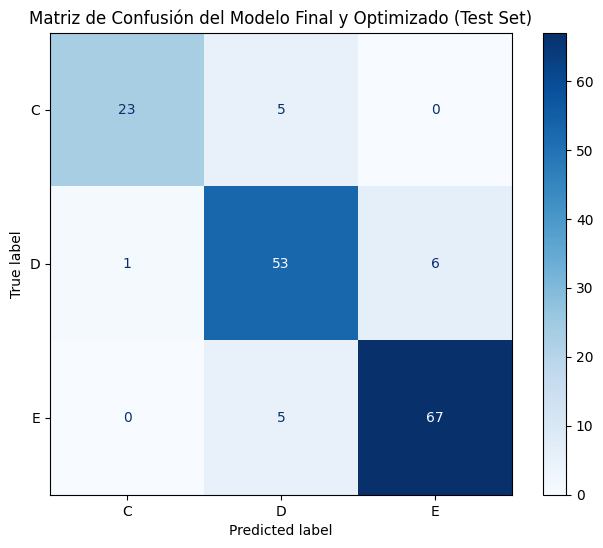

In [36]:
# ===================================================================================
# PASO FINAL: AFINAMIENTO EXHAUSTIVO CON GRIDSEARCHCV EN UNA REJILLA REDUCIDA
# ===================================================================================
from sklearn.model_selection import GridSearchCV # Volvemos a GridSearchCV para la búsqueda fina

# Los mejores parámetros encontrados en la búsqueda aleatoria anterior:
# 'subsample': 0.9, 'reg_lambda': 0.01, 'reg_alpha': 0, 'n_estimators': 1000, 
# 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0

print("--- Iniciando la fase de Afinamiento Final ---")

# --- PASO 1: Definir la Rejilla de Afinamiento ---
# Creamos una rejilla muy pequeña centrada en los mejores valores encontrados.
param_grid_final_tuning = {
    'classifier__n_estimators': [900, 1000, 1100],            # Alrededor de 1000
    'classifier__learning_rate': [0.008, 0.01, 0.015],         # Alrededor de 0.01
    'classifier__max_depth': [2, 3, 4],                      # Alrededor de 3
    
    # Mantenemos los siguientes parámetros fijos en su mejor valor encontrado,
    # ya que son menos sensibles o ya están en un óptimo probable.
    'classifier__subsample': [0.9],
    'classifier__colsample_bytree': [1.0],
    'classifier__gamma': [0.1],
    'classifier__reg_alpha': [0],
    'classifier__reg_lambda': [0.01]
}

# --- PASO 2: Configurar y Ejecutar GridSearchCV ---
# El pipeline y la estrategia de validación cruzada no cambian.
# La búsqueda será rápida porque la rejilla es muy pequeña.
final_grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid_final_tuning,
    cv=cv_strategy, # Usamos la misma cv_strategy (ej: 4 o 5 folds)
    n_jobs=-1,
    verbose=2,
    scoring='f1_weighted'
)

print("\nIniciando búsqueda de afinamiento final...")
final_grid_search.fit(X_train_final, y_train_encoded)

# --- PASO 3: Analizar y Evaluar el Modelo Definitivo ---
print("\n¡Afinamiento final completado!")

print("\nLos hiperparámetros definitivos y óptimos son:")
print(final_grid_search.best_params_)

print("\nMejor F1-Score (ponderado) en validación cruzada tras el afinamiento:")
print(final_grid_search.best_score_)

# Este es tu modelo final, listo para producción
final_best_model = final_grid_search.best_estimator_

print("\n--- Evaluación del Modelo Definitivo en el Conjunto de Prueba ---")
y_pred_final = final_best_model.predict(X_test_final)

print(classification_report(y_test_encoded, y_pred_final, target_names=label_encoder.classes_))

print("\nMatriz de Confusión del Modelo Definitivo:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(final_best_model, X_test_final, y_test_encoded,
                                      display_labels=label_encoder.classes_,
                                      cmap=plt.cm.Blues,
                                      ax=ax)
plt.title("Matriz de Confusión del Modelo Final y Optimizado (Test Set)")
plt.show()

# ===================================================================================
# --- FIN DEL PROYECTO DE MODELADO ---
# ===================================================================================

Exportar 